In [1]:
!pip install pandas numpy matplotlib scikit-learn seaborn

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para exibir gráficos diretamente no notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

In [3]:
# Carregar o novo arquivo CSV
caminho_arquivo = '2025/base_senado_pronta_mineracao.csv'
df_bruto = pd.read_csv(caminho_arquivo, delimiter=';')

# Filtrar apenas o ano de exercício de 2025
df_2025 = df_bruto[df_bruto['ANO EXERCÍCIO'] == 2025].copy()

print(f"Total de registros em 2025: {df_2025.shape[0]}")
df_2025[['LOTAÇÃO EXERCÍCIO', 'HORAS_EXTRAS', 'REM_LIQUIDA', 'MES_REFERENCIA']].head()

Total de registros em 2025: 8937


,LOTAÇÃO EXERCÍCIO,HORAS_EXTRAS,REM_LIQUIDA,MES_REFERENCIA
363,GABINETE DA SENADORA IVETE DA SILVEIRA,0.0,1725.48,1
466,GABINETE DO SENADOR MAGNO MALTA,0.0,2745.10,1
471,GABINETE DO SENADOR MAGNO MALTA,0.0,2198.45,1
472,GABINETE DA LIDERANÇA DA BANCADA FEMININA,0.0,2293.04,1
473,GABINETE DA LIDERANÇA DO PODEMOS,0.0,1725.48,1


In [4]:
# Garantir que as colunas críticas sejam lidas como números (floats)
df_2025['HORAS_EXTRAS'] = pd.to_numeric(df_2025['HORAS_EXTRAS'], errors='coerce').fillna(0)
df_2025['REM_LIQUIDA'] = pd.to_numeric(df_2025['REM_LIQUIDA'], errors='coerce').fillna(0)

# Agrupando por Departamento e Mês para entender a flutuação ao longo de 2025
Agrupado_Mes = df_2025.groupby(['LOTAÇÃO EXERCÍCIO', 'MES_REFERENCIA']).agg(
    Total_Horas_Extras=('HORAS_EXTRAS', 'sum'),
    Total_Folha=('REM_LIQUIDA', 'sum')
).reset_index()

# Consolidação final por Departamento (Métricas do K-means)
df_departamentos = Agrupado_Mes.groupby('LOTAÇÃO EXERCÍCIO').agg(
    Gasto_Medio_HE=('Total_Horas_Extras', 'mean'),
    Volatilidade_HE=('Total_Horas_Extras', 'std'),
    Gasto_Total_Folha=('Total_Folha', 'mean')
).reset_index()

# Tratamento de valores nulos no Desvio Padrão (Volatilidade)
df_departamentos['Volatilidade_HE'] = df_departamentos['Volatilidade_HE'].fillna(0)

# Cálculo do impacto percentual das Horas Extras na folha do departamento
df_departamentos['Percentual_HE_Na_Folha'] = (df_departamentos['Gasto_Medio_HE'] / df_departamentos['Gasto_Total_Folha']) * 100
df_departamentos['Percentual_HE_Na_Folha'] = df_departamentos['Percentual_HE_Na_Folha'].fillna(0)

# Filtrar apenas departamentos que registraram gastos com HE em 2025
df_analise = df_departamentos[df_departamentos['Gasto_Medio_HE'] > 0].reset_index(drop=True)

print(f"Total de departamentos com Horas Extras em 2025: {df_analise.shape[0]}")
df_analise.head()

Total de departamentos com Horas Extras em 2025: 38


,LOTAÇÃO EXERCÍCIO,Gasto_Medio_HE,Volatilidade_HE,Gasto_Total_Folha,Percentual_HE_Na_Folha
0,BLOCO PARLAM. DEMOCRACIA (MDB/UNIÃO/PODEMOS/PSDB),476.470000,433.039939,32094.713750,1.484575
1,BLOCO PARLAMENTAR VANGUARDA (PL/NOVO),1726.918333,1355.833465,8579.193333,20.129146
2,COORDENAÇÃO DE EVENTOS,35.985000,88.144888,2989.206667,1.203831
3,DIRETORIA-EXECUTIVA DE GOV. CONTRAT. E LICITAT...,119.278889,357.836667,54495.978889,0.218876
4,GABINETE DA DGER,1070.375714,1428.635409,56298.100000,1.901264


In [5]:
# Variáveis que o K-means usará para comparar os setores
atributos = ['Gasto_Medio_HE', 'Volatilidade_HE', 'Percentual_HE_Na_Folha']
X = df_analise[atributos]

# Colocando os dados na mesma escala (Média=0, Desvio Padrão=1)
scaler = StandardScaler()
X_escalonado = scaler.fit_transform(X)

print("Dados prontos e normalizados!")

Dados prontos e normalizados!


In [6]:
# Definindo 3 grupos de comportamento
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Treinando o modelo e aplicando os rótulos de grupo (0, 1 ou 2)
df_analise['Cluster'] = kmeans.fit(X_escalonado)

# Exibir a média de cada grupo para você entender o perfil de cada um
print("=== Perfil Médio de Cada Cluster ===")
print(df_analise.groupby('Cluster')[atributos].mean())

=== Perfil Médio de Cada Cluster ===
                                                  Gasto_Medio_HE  \
Cluster                                                            
KMeans(n_clusters=3, n_init=10, random_state=42)     1600.482674   

                                                  Volatilidade_HE  \
Cluster                                                             
KMeans(n_clusters=3, n_init=10, random_state=42)      1222.730902   

                                                  Percentual_HE_Na_Folha  
Cluster                                                                   
KMeans(n_clusters=3, n_init=10, random_state=42)                6.916285  


d:\Nova pasta\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


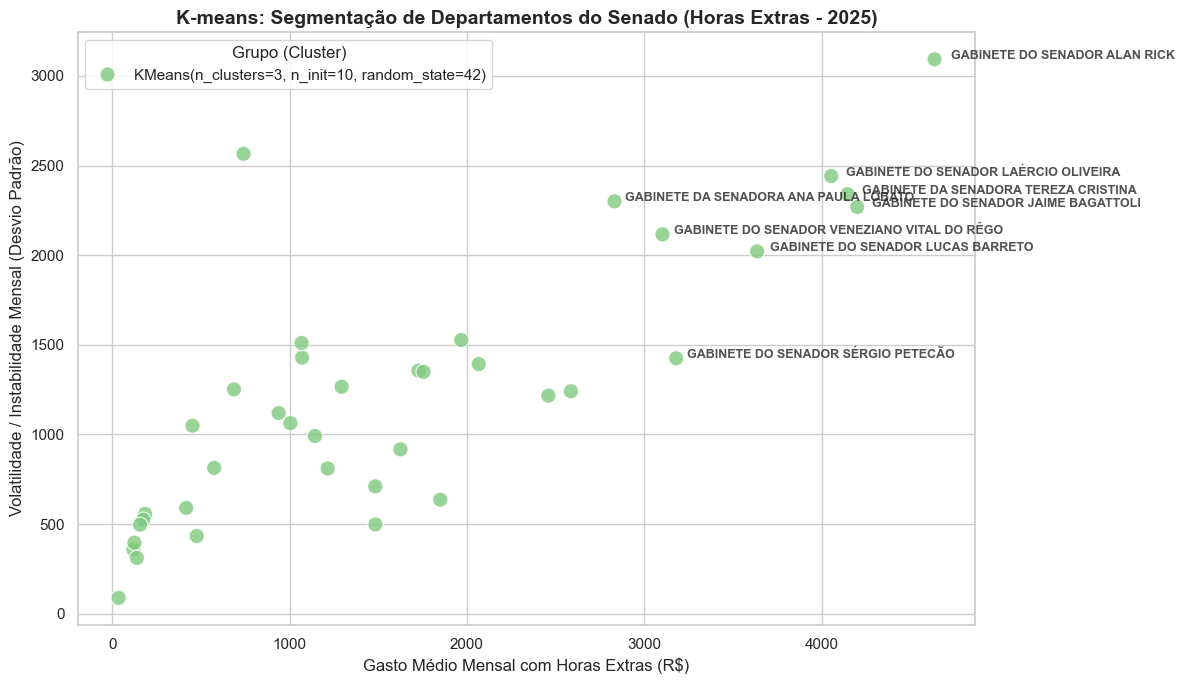

In [7]:
plt.figure(figsize=(12, 7))

# Plot dos pontos de cada departamento
sns.scatterplot(
    data=df_analise,
    x='Gasto_Medio_HE',
    y='Volatilidade_HE',
    hue='Cluster',
    palette='Accent',
    s=120,
    alpha=0.8
)

# Colocar etiquetas nos 8 maiores departamentos para melhor leitura
top_gastos = df_analise.nlargest(8, 'Gasto_Medio_HE')
for idx, row in top_gastos.iterrows():
    plt.text(
        row['Gasto_Medio_HE'] * 1.02,
        row['Volatilidade_HE'],
        row['LOTAÇÃO EXERCÍCIO'],
        fontsize=9,
        fontweight='semibold',
        alpha=0.8
    )

plt.title('K-means: Segmentação de Departamentos do Senado (Horas Extras - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Gasto Médio Mensal com Horas Extras (R$)', fontsize=12)
plt.ylabel('Volatilidade / Instabilidade Mensal (Desvio Padrão)', fontsize=12)
plt.legend(title='Grupo (Cluster)')
plt.tight_layout()
plt.show()

In [8]:
# Criar tabela final ordenada pelo grupo e valor de gasto
relatorio_final = df_analise[['Cluster', 'LOTAÇÃO EXERCÍCIO', 'Gasto_Medio_HE', 'Percentual_HE_Na_Folha']].sort_values(by=['Cluster', 'Percentual_HE_Na_Folha'], ascending=[True, False])

# Exibe o topo da lista estruturada
relatorio_final.head(30)

,Cluster,LOTAÇÃO EXERCÍCIO,Gasto_Medio_HE,Percentual_HE_Na_Folha
19,"KMeans(n_clusters=3, n_init=10, random_state=42)",GABINETE DO SENADOR JAYME CAMPOS,1484.478333,22.331316
17,"KMeans(n_clusters=3, n_init=10, random_state=42)",GABINETE DO SENADOR IRAJÁ,1483.200000,21.129555
1,"KMeans(n_clusters=3, n_init=10, random_state=42)",BLOCO PARLAMENTAR VANGUARDA (PL/NOVO),1726.918333,20.129146
12,"KMeans(n_clusters=3, n_init=10, random_state=42)",GABINETE DA SENADORA TEREZA CRISTINA,4147.243636,19.815991
16,"KMeans(n_clusters=3, n_init=10, random_state=42)",GABINETE DO SENADOR FERNANDO FARIAS,1143.040000,19.416385
18,"KMeans(n_clusters=3, n_init=10, random_state=42)",GABINETE DO SENADOR JAIME BAGATTOLI,4201.556667,15.394455
8,"KMeans(n_clusters=3, n_init=10, random_state=42)",GABINETE DA SENADORA ANA PAULA LOBATO,2832.685833,12.540284
28,"KMeans(n_clusters=3, n_init=10, random_state=42)",GABINETE DO SENADOR STYVENSON VALENTIM,2459.667273,12.097499
30,"KMeans(n_clusters=3, n_init=10, random_state=42)",GABINETE DO SENADOR VANDERLAN CARDOSO,1625.451667,10.102967
26,"KMeans(n_clusters=3, n_init=10, random_state=42)",GABINETE DO SENADOR PEDRO CHAVES,1849.762500,9.846020
